In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "training_data"

sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)

PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data


In [2]:
from src.data.io import load_graph_dataset_from_dir
from src.data.metadata import load_aux_metadata_for_dir, attach_metadata_to_graphs, load_marker_names_from_dir

# Load all organoids
data_dir = PROJECT_ROOT / "training_data" / "smooth_cryptdist"
graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")

meta = load_aux_metadata_for_dir(str(data_dir))
attach_metadata_to_graphs(graphs, meta)

marker_names = load_marker_names_from_dir(data_dir)

Loaded 1135 graphs; skipped 0.
Loaded 1135 organoids.


In [ ]:
# Optional day3p5 timepoint filter
from src.data.filters import filter_graphs_by_metadata

DAY3P5_TIMEPOINT = "day3p5"

# Default: remove day3p5 graphs if present.
graphs = filter_graphs_by_metadata(
    graphs,
    key="timepoint",
    drop_values={DAY3P5_TIMEPOINT},
    missing="keep",
    inplace=False,
    print_summary=True,
)

# Alternative: keep only day3p5 graphs and filter out all other timepoints.
# Uncomment this block and comment out the default block above if needed.
# graphs = filter_graphs_by_metadata(
#     graphs,
#     key="timepoint",
#     keep_values={DAY3P5_TIMEPOINT},
#     missing="drop",
#     inplace=False,
#     print_summary=True,
# )


In [3]:
from src.data.metadata import print_graph_and_metadata_fields

print_graph_and_metadata_fields(graphs)

Graph fields:
  - _edge_attr_cls
  - _store
  - _tensor_attr_cls

Metadata fields (g.meta):
  - cell_patch_area
  - complexity
  - d_crypts_graph
  - d_crypts_mesh_shape
  - dataset
  - deleted_node_ids
  - graph_path
  - kept_node_ids
  - label_uid
  - mesh_path
  - new_to_old_index
  - num_deleted_nodes
  - num_nodes
  - old_to_new_index
  - organoid_id
  - original_num_nodes
  - proj_vertex_ids
  - segmentation_path
  - timepoint
  - total_curvature_discrete
  - total_surface_area
  - total_volume
  - voronoi_vertex_owner


In [4]:
from src.data.metadata import fill_missing_metadata_for_group

graphs = fill_missing_metadata_for_group(
    graphs,
    field="complexity",
    fill_value=2.1,
    dataset="20251201",
    timepoint="day4p5",
)

In [5]:
from src.data.metadata import filter_graphs_by_numeric_metadata

graphs = filter_graphs_by_numeric_metadata(
    graphs,
    key="complexity",
    min_value=2.0,
    allow_missing=False,
    inplace=False,
    print_summary=True,
)


filter_graphs_by_numeric_metadata(key='complexity', min_value=2.0, max_value=None): kept 794 / 1135 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                195    342    0.570
20250929         day4p5               75    104    0.721
20250929         day4p5-more         246    411    0.599
20251201         day4p5              278    278    1.000


In [6]:
from src.data.metadata import filter_graphs_by_sphericity

graphs = filter_graphs_by_sphericity(
    graphs,
    max_sphericity=0.915,
    print_summary=True,
)


filter_graphs_by_sphericity(max_sphericity=0.915): kept 700 / 794 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                193    195    0.990
20250929         day4p5               74     75    0.987
20250929         day4p5-more         240    246    0.976
20251201         day4p5              193    278    0.694


In [7]:
from collections import defaultdict

from src.data.nxgraphs import pyg_graph_to_nx
from organograph.graph.stats import build_weight_matrix_kNN, permutation_test_morans_I
from src.data.metadata import get_graph_metadata

def compute_morans_by_graph_group_and_k(
    graphs,
    *,
    marker_names,
    ks=(1, 2, 3),
    n_perms=999,
    seed=0,
    meta_lookup=None,
    row_standardize=False,
):
    from collections import defaultdict
    import numpy as np

    results = {
        k: defaultdict(lambda: {
            "I_obs": [],
            "I_perm": [],
            "p_values": [],
            "organoid_str": [],
        })
        for k in ks
    }

    for gi, g in enumerate(graphs):
        md = get_graph_metadata(g, meta_lookup=meta_lookup, strict=True)
        dataset = md.get("dataset")
        timepoint = md.get("timepoint")
        group_key = f"{dataset} | {timepoint}"

        G = pyg_graph_to_nx(g, marker_names=marker_names)
        X = g.x.detach().cpu().numpy()

        for k in ks:
            W, nodes = build_weight_matrix_kNN(
                G,
                k=k,
                row_standardize=row_standardize,
            )

            # Compute cross-Moran's I for all marker pairs: (M, M)
            I_obs, local_I, I_perm, p_values = permutation_test_morans_I(
                X,
                W,
                Y=X,
                n_perms=n_perms,
                seed=None if seed is None else seed + 1000 * gi + k,
            )

            results[k][group_key]["I_obs"].append(I_obs)
            results[k][group_key]["I_perm"].append(I_perm)
            results[k][group_key]["p_values"].append(p_values)
            results[k][group_key]["organoid_str"].append(
                getattr(g, "organoid_str", None)
            )

    for k in ks:
        for group_key in results[k]:
            results[k][group_key]["I_obs"] = np.asarray(
                results[k][group_key]["I_obs"]
            )       # (n_org, M, M)

            results[k][group_key]["I_perm"] = np.asarray(
                results[k][group_key]["I_perm"]
            )      # (n_org, n_perms, M, M)

            results[k][group_key]["p_values"] = np.asarray(
                results[k][group_key]["p_values"]
            )      # (n_org, M, M)

    return results

In [8]:
morans_results = compute_morans_by_graph_group_and_k(
    graphs,
    marker_names=marker_names,
    ks=(1, 2, 3),
    n_perms=999,
    seed=0,
    meta_lookup=None,  # or your metadata lookup
)

/home/fmoller/Projects/LearningOrganoids/OrganoGraph/src/organograph/graph/stats.py:186: RuntimeWarning: invalid value encountered in divide
  global_I = (N / S0) * (Z_X.T @ W @ Z_Y) / np.sum(Z_X**2, axis=0)[:, None]
/home/fmoller/Projects/LearningOrganoids/OrganoGraph/src/organograph/graph/stats.py:188: RuntimeWarning: invalid value encountered in divide
  local_I = (Z_X[:, :, None] / m2_X[None, :, None]) * WZ_Y[:, None, :]


In [9]:
import numpy as np
import matplotlib.pyplot as plt


def plot_morans_by_group_for_k(
    morans_results,
    k,
    *,
    marker_names,
    source_marker_names=("Serotonin", "Lysozyme", "LGR5"),
    target_marker_names=("Serotonin", "Lysozyme", "LGR5", "AldoB", "KI67"),
    use_percentiles=True,
    lower_q=2.5,
    upper_q=97.5,
    figsize_scale=(2.7, 1.7),
):
    source_indices = [marker_names.index(m) for m in source_marker_names]
    target_indices = [marker_names.index(m) for m in target_marker_names]

    group_keys = sorted(morans_results[k].keys())
    x = np.arange(len(group_keys))

    n_cols = len(source_marker_names)
    n_rows = len(target_marker_names)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_scale[0] * n_cols, figsize_scale[1] * n_rows),
        sharex=True,
        constrained_layout=True,
    )

    axes = np.atleast_2d(axes)

    for col, (source_name, i_source) in enumerate(zip(source_marker_names, source_indices)):
        for row, (target_name, j_target) in enumerate(zip(target_marker_names, target_indices)):
            ax = axes[row, col]

            obs_means = []
            null_means = []
            null_lower = []
            null_upper = []

            for group_key in group_keys:
                res = morans_results[k][group_key]

                I_obs = res["I_obs"][:, i_source, j_target]
                I_perm = res["I_perm"][:, :, i_source, j_target]

                obs_means.append(np.nanmean(I_obs))

                I_perm_flat = I_perm.ravel()
                I_perm_flat = I_perm_flat[np.isfinite(I_perm_flat)]

                if I_perm_flat.size == 0:
                    null_means.append(np.nan)
                    null_lower.append(np.nan)
                    null_upper.append(np.nan)
                else:
                    null_means.append(np.mean(I_perm_flat))

                    if use_percentiles:
                        lo, hi = np.percentile(I_perm_flat, [lower_q, upper_q])
                    else:
                        mu, sigma = np.mean(I_perm_flat), np.std(I_perm_flat)
                        lo, hi = mu - 2 * sigma, mu + 2 * sigma

                    null_lower.append(lo)
                    null_upper.append(hi)

            obs_means = np.asarray(obs_means)
            null_means = np.asarray(null_means)
            null_lower = np.asarray(null_lower)
            null_upper = np.asarray(null_upper)

            ax.fill_between(
                x,
                null_lower,
                null_upper,
                color="gray",
                alpha=0.3,
                label="Null 95%" if use_percentiles else "Null ±2σ",
            )

            ax.plot(
                x,
                null_means,
                color="gray",
                linestyle="--",
                lw=1,
                label="Null mean",
            )

            ax.plot(
                x,
                obs_means,
                "o-",
                color="tab:red",
                lw=2,
                label="Observed",
            )

            if row == 0:
                ax.set_title(f"Source: {source_name}", fontsize=10)

            if col == 0:
                ax.set_ylabel(f"Target: {target_name}\nMoran's I")

            ax.grid(alpha=0.3)

    for ax in axes[-1, :]:
        ax.set_xticks(x)
        ax.set_xticklabels(group_keys, rotation=45, ha="right")
        ax.set_xlabel("dataset | timepoint")

    for row in range(n_rows):
        axs = axes[row, :]
        ymin = min(ax.get_ylim()[0] for ax in axs)
        ymax = max(ax.get_ylim()[1] for ax in axs)
        ylim = max(abs(ymin), abs(ymax))
        for ax in axs:
            ax.set_ylim(-ylim, ylim)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.02, 1.0))

    fig.suptitle(f"Cross-Moran's I by dataset/timepoint | k={k}", fontweight="bold")

    return fig, axes

In [10]:
def plot_morans_combined_vs_k(
    morans_results,
    *,
    marker_names,
    ks=(1, 2, 3),
    source_marker_names=("Serotonin", "Lysozyme", "LGR5"),
    target_marker_names=("Serotonin", "Lysozyme", "LGR5", "AldoB", "KI67"),
    use_percentiles=True,
    lower_q=2.5,
    upper_q=97.5,
    figsize_scale=(2.7, 1.7),
):
    source_indices = [marker_names.index(m) for m in source_marker_names]
    target_indices = [marker_names.index(m) for m in target_marker_names]

    ks = list(ks)
    x = np.asarray(ks)

    n_cols = len(source_marker_names)
    n_rows = len(target_marker_names)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_scale[0] * n_cols, figsize_scale[1] * n_rows),
        sharex=True,
        constrained_layout=True,
    )

    axes = np.atleast_2d(axes)

    for col, (source_name, i_source) in enumerate(zip(source_marker_names, source_indices)):
        for row, (target_name, j_target) in enumerate(zip(target_marker_names, target_indices)):
            ax = axes[row, col]

            obs_means = []
            null_means = []
            null_lower = []
            null_upper = []

            for k in ks:
                I_obs_all = []
                I_perm_all = []

                for group_key, res in morans_results[k].items():
                    I_obs_all.append(res["I_obs"][:, i_source, j_target])
                    I_perm_all.append(res["I_perm"][:, :, i_source, j_target].ravel())

                I_obs_all = np.concatenate(I_obs_all)
                I_perm_all = np.concatenate(I_perm_all)
                I_perm_all = I_perm_all[np.isfinite(I_perm_all)]

                obs_means.append(np.nanmean(I_obs_all))

                if I_perm_all.size == 0:
                    null_means.append(np.nan)
                    null_lower.append(np.nan)
                    null_upper.append(np.nan)
                else:
                    null_means.append(np.mean(I_perm_all))

                    if use_percentiles:
                        lo, hi = np.percentile(I_perm_all, [lower_q, upper_q])
                    else:
                        mu, sigma = np.mean(I_perm_all), np.std(I_perm_all)
                        lo, hi = mu - 2 * sigma, mu + 2 * sigma

                    null_lower.append(lo)
                    null_upper.append(hi)

            obs_means = np.asarray(obs_means)
            null_means = np.asarray(null_means)
            null_lower = np.asarray(null_lower)
            null_upper = np.asarray(null_upper)

            ax.fill_between(
                x,
                null_lower,
                null_upper,
                color="gray",
                alpha=0.3,
                label="Null 95%" if use_percentiles else "Null ±2σ",
            )

            ax.plot(
                x,
                null_means,
                color="gray",
                linestyle="--",
                lw=1,
                label="Null mean",
            )

            ax.plot(
                x,
                obs_means,
                "o-",
                color="tab:red",
                lw=2,
                label="Observed",
            )

            if row == 0:
                ax.set_title(f"Source: {source_name}", fontsize=10)

            if col == 0:
                ax.set_ylabel(f"Target: {target_name}\nMoran's I")

            ax.set_xticks(x)
            ax.grid(alpha=0.3)

    for ax in axes[-1, :]:
        ax.set_xlabel("k-hop neighborhood")

    for row in range(n_rows):
        axs = axes[row, :]
        ymin = min(ax.get_ylim()[0] for ax in axs)
        ymax = max(ax.get_ylim()[1] for ax in axs)
        ylim = max(abs(ymin), abs(ymax))
        for ax in axs:
            ax.set_ylim(-ylim, ylim)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.02, 1.0))

    fig.suptitle("Cross-Moran's I vs k | all datasets combined", fontweight="bold")

    return fig, axes

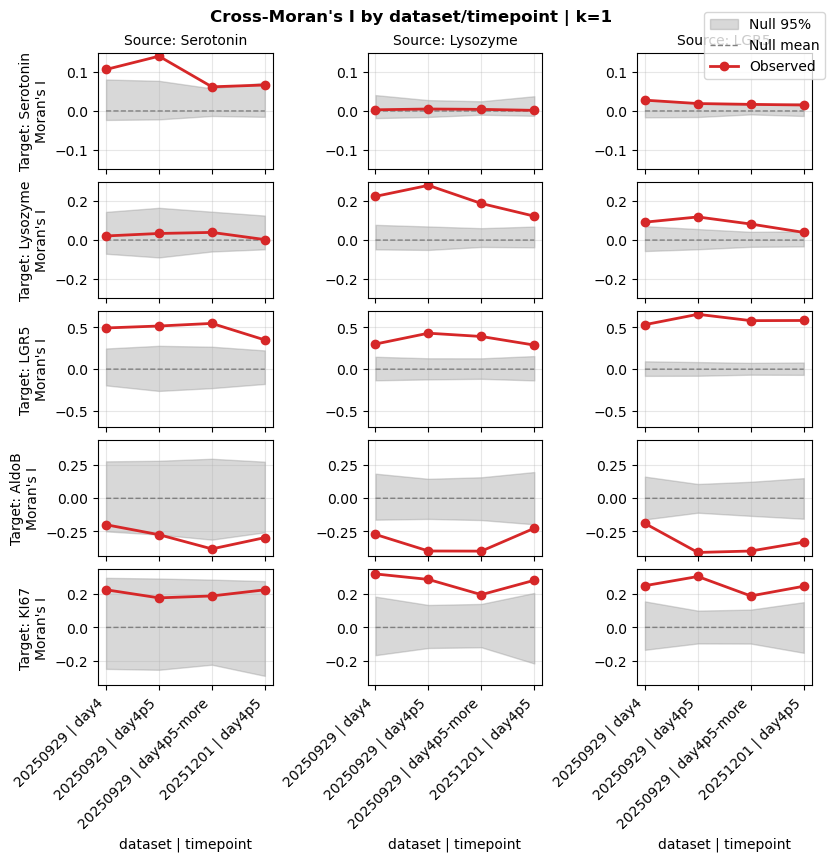

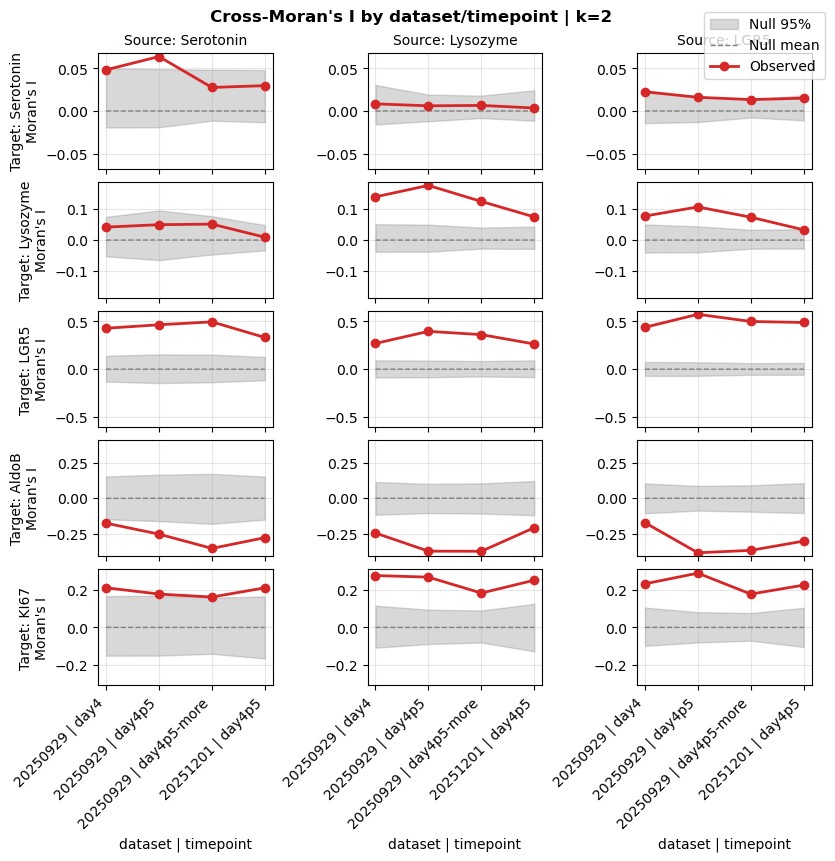

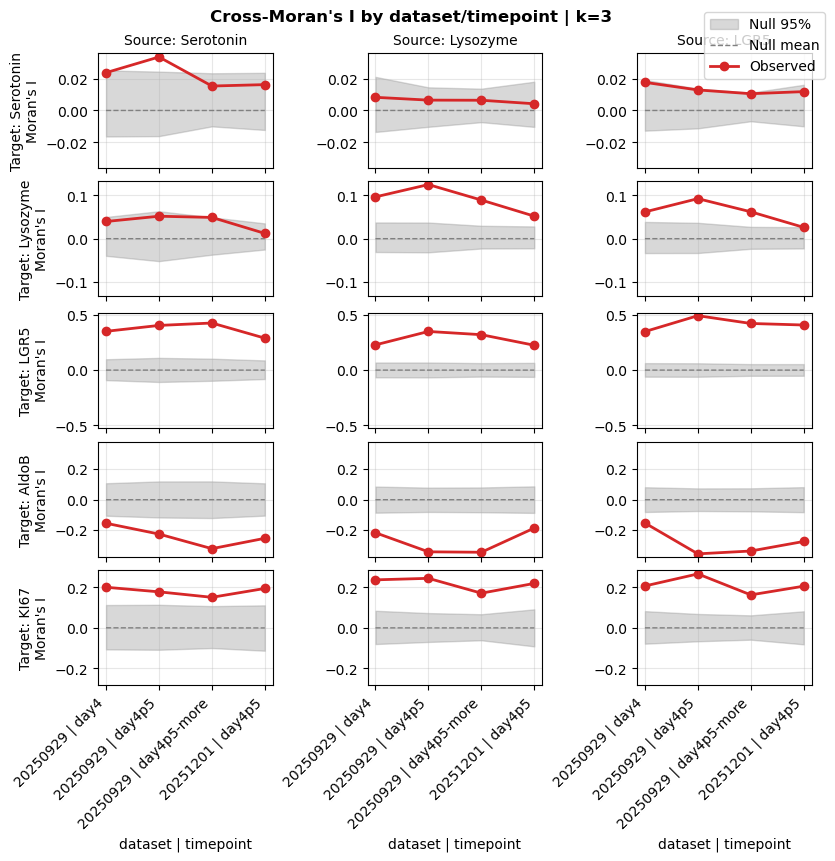

In [11]:
for k in (1, 2, 3):
    fig, axes = plot_morans_by_group_for_k(
        morans_results,
        k,
        marker_names=marker_names,
        source_marker_names=["Serotonin", "Lysozyme", "LGR5"],
        target_marker_names=["Serotonin", "Lysozyme", "LGR5", "AldoB", "KI67"],
    )
    plt.show()

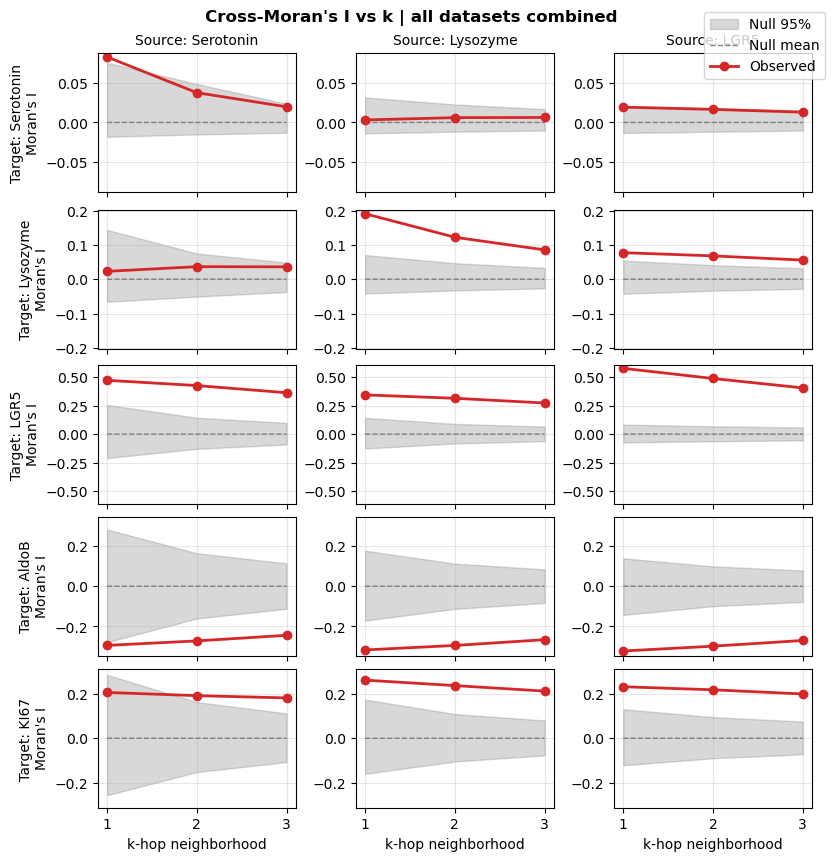

In [12]:
fig, axes = plot_morans_combined_vs_k(
    morans_results,
    marker_names=marker_names,
    ks=(1, 2, 3),
    source_marker_names=["Serotonin", "Lysozyme", "LGR5"],
    target_marker_names=["Serotonin", "Lysozyme", "LGR5", "AldoB", "KI67"],
)

plt.show()